digontobiswas.kp.bd@gmail.com

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Data Load

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Phitron AI ML/Machine learning/Final Exam/water_potability.csv')
print(df.head())
print(df.shape)
print(df.info())
print(df.describe)

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
(3276, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dty

# Data Preprocessing

In [6]:
print(df.isnull().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [7]:
df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].mean())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())

### Outlier Check

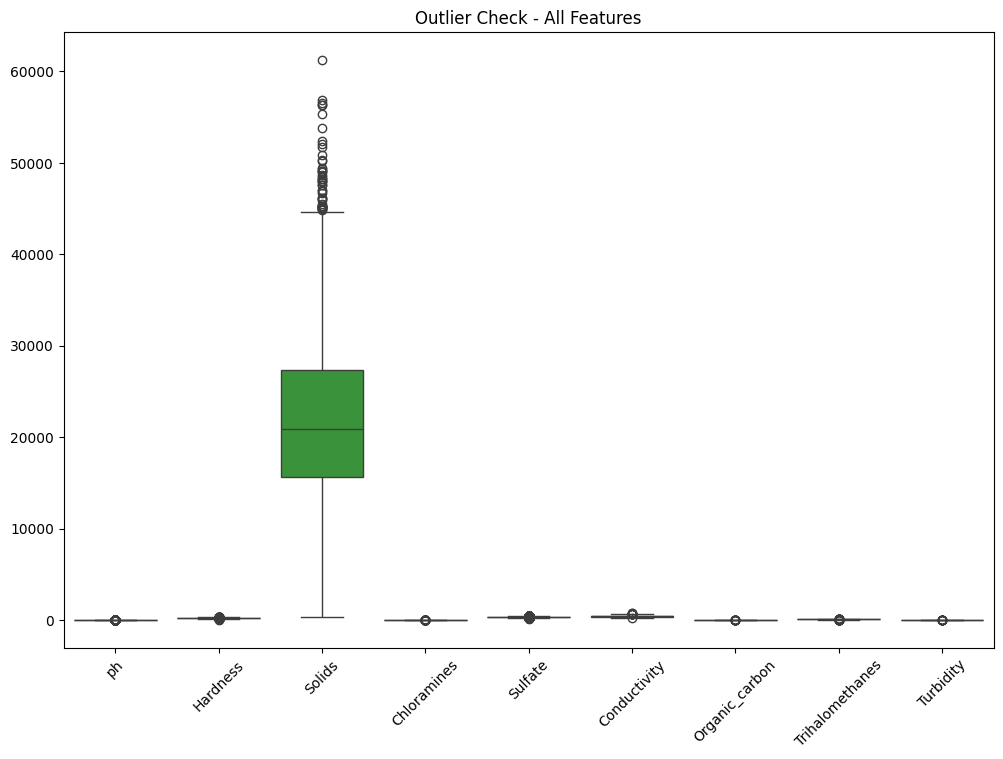

In [8]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df.drop('Potability', axis=1))
plt.xticks(rotation=45)
plt.title("Outlier Check - All Features")
plt.show()

### Correlation Heatmap

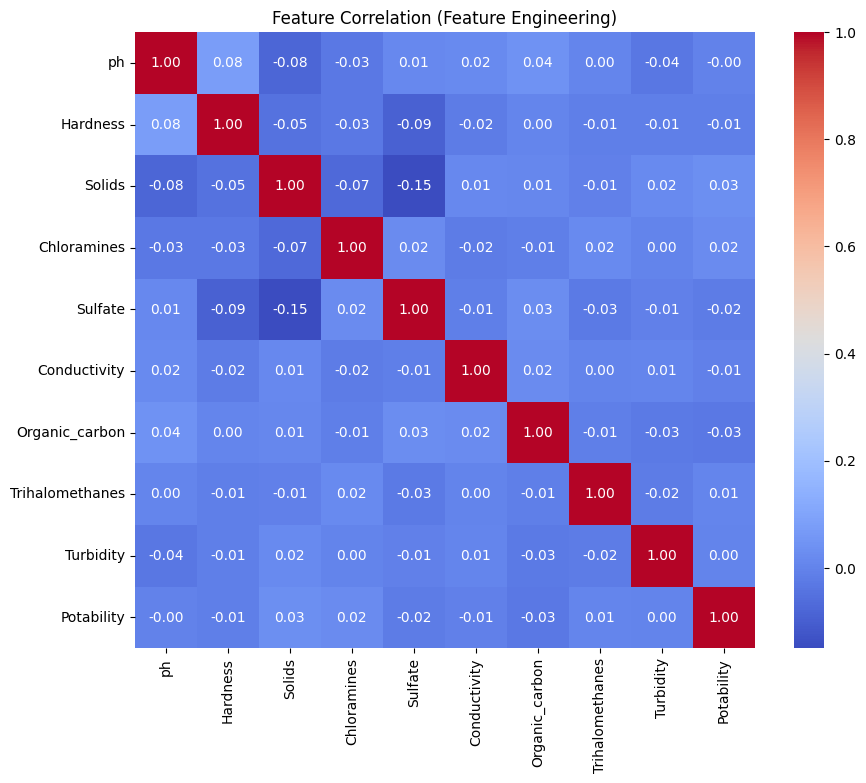

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation (Feature Engineering)")
plt.show()

In [10]:
X = df.drop('Potability', axis=1)
y = df['Potability']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [14]:
numerical_features = X.columns.tolist()
numerical_features

['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity']

# Pipeline

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ],
)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
print(model_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['ph', 'Hardness', 'Solids',
                                                   'Chloramines', 'Sulfate',
                                                   'Conductivity',
                                                   'Organic_carbon',
                                                   'Trihalomethanes',
                                                   'Turbidity'])])),
                ('classifier', RandomForestClassifier(random_state=42))])


# Primary Model Selection
- Inside my pipeline section i select RandomForestClassifier. The reason behind it, the problem is binary classification problem. and data is tabular numerical data. For those type of problem this is suitable. it reduce overfitrting problem for using ensumble multiple DT use.

# Model Traning

In [18]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['ph', 'Hardness', 'Solids',
                                                   'Chloramines', 'Sulfate',
                                                   'Conductivity',
                                                   'Organic_carbon',
                                                   'Trihalomethanes',
                                                   'Turbidity'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

# ross-Validation

In [19]:
cv_scores = cross_val_score(model_pipeline, X_train, y_train,
                            cv=5,
                            scoring='accuracy',
                            n_jobs=-1)

print("CV Acc Scor:", cv_scores)
print("AVG CV Acc:", cv_scores.mean())
print("CV STD:", cv_scores.std())

CV Acc Scor: [0.67175573 0.65839695 0.66030534 0.6870229  0.66603053]
AVG CV Acc: 0.668702290076336
CV STD: 0.010284117240692748


# Hyperparameter Tuning

In [20]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(model_pipeline, param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Parameter Test:", param_grid)
print("Best Parameter:", grid_search.best_params_)
print("Best cv Acc:", grid_search.best_score_)

Parameter Test: {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10, 20, None], 'classifier__min_samples_split': [2, 5]}
Best Parameter: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best cv Acc: 0.682442748091603


# Best Model Selection

In [23]:
best_model = grid_search.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['ph', 'Hardness', 'Solids',
                                                   'Chloramines', 'Sulfate',
                                                   'Conductivity',
                                                   'Organic_carbon',
                                                   'Trihalomethanes',
                                                   'Turbidity'])])),
                ('classifier',
                 RandomForestClassifier(min_samples_split=5, random_state=42))])

# Best Model Selection

In [24]:
y_pred = best_model.predict(X_test)
print("ACC-", accuracy_score(y_test, y_pred))
print("\nClassification Report-\n", classification_report(y_test, y_pred))
print("\nCM:\n", confusion_matrix(y_test, y_pred))

ACC- 0.676829268292683

Classification Report-
               precision    recall  f1-score   support

           0       0.69      0.88      0.77       412
           1       0.62      0.34      0.44       244

    accuracy                           0.68       656
   macro avg       0.66      0.61      0.61       656
weighted avg       0.66      0.68      0.65       656


CM:
 [[361  51]
 [161  83]]
